In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

from config import DATA_PROCESSED, OUTPUTS_DIR, OUTPUT_FLOOR, IRB_LGD_BASE

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "font.size"        : 11,
})

df = pd.read_parquet(DATA_PROCESSED / "model_dataset.parquet")
print(f"Dataset loaded: {len(df):,} loans")
print(f"Columns: {[c for c in df.columns if 'irb' in c or 'floor' in c or 'sa' in c]}")

Dataset loaded: 4,464,305 loans
Columns: ['msa', 'sa_rw', 'sa_rwa', 'floor_ratio', 'floor_binds', 'floor_rwa', 'irb_rw_logistic', 'irb_rwa_logistic']


In [2]:
# Aggregate the key metrics by FICO band
band_stats = (
    df.groupby("fico_band", observed=True)
    .agg(
        loans        = ("floor_ratio", "count"),
        mean_pd      = ("pd_logistic", "mean"),
        mean_irb_rw  = ("irb_rw_logistic", "mean"),
        mean_sa_rw   = ("sa_rw", "mean"),
        mean_ratio   = ("floor_ratio", "mean"),
        median_ratio = ("floor_ratio", "median"),
        std_ratio    = ("floor_ratio", "std"),
        n_binds      = ("floor_binds", "sum"),
    )
    .reset_index()
)

band_stats["bind_rate_pct"] = (
    band_stats["n_binds"] / band_stats["loans"] * 100
)
band_stats["mean_pd_pct"]     = band_stats["mean_pd"]    * 100
band_stats["mean_irb_rw_pct"] = band_stats["mean_irb_rw"] * 100
band_stats["mean_sa_rw_pct"]  = band_stats["mean_sa_rw"]  * 100

print("H1 analysis — output floor summary by FICO band:")
print("=" * 85)
display_cols = ["fico_band", "loans", "mean_pd_pct", "mean_irb_rw_pct",
                "mean_sa_rw_pct", "mean_ratio", "n_binds", "bind_rate_pct"]
print(band_stats[display_cols].to_string(index=False, float_format="%.3f"))

# Save for dissertation
band_stats.to_csv(OUTPUTS_DIR / "table2_h1_floor_summary.csv", index=False)
print("\nSaved table2_h1_floor_summary.csv")

H1 analysis — output floor summary by FICO band:
           fico_band   loans  mean_pd_pct  mean_irb_rw_pct  mean_sa_rw_pct  mean_ratio  n_binds  bind_rate_pct
     <620 (subprime)    2723       15.357           41.144          27.115       1.543       23          0.845
620–659 (near-prime)  158929       13.942           38.542          31.052       1.288     7950          5.002
     660–719 (prime)  975271        8.758           27.833          33.954       0.852   372490         38.193
    720–759 (prime+) 1163071        4.849           18.507          34.729       0.550   940014         80.822
  760+ (super-prime) 2164311        2.357           10.906          32.370       0.344  2130448         98.435

Saved table2_h1_floor_summary.csv


In [3]:
# Kruskal-Wallis test: are the floor_ratio distributions
# significantly different across FICO bands?
#
# Why Kruskal-Wallis and not ANOVA?
# ANOVA assumes normally distributed residuals. Floor ratios are
# right-skewed (bounded at 0, long upper tail). Kruskal-Wallis is
# the non-parametric equivalent — it tests whether the distributions
# across groups are drawn from the same population, without assuming
# normality. It ranks all observations and tests whether the mean
# ranks differ across groups.
#
# H0: the floor_ratio distribution is identical across FICO bands
# H1: at least one band has a different distribution
# Reject H0 if p-value < 0.05

groups = [
    df.loc[df["fico_band"] == band, "floor_ratio"].dropna().values
    for band in df["fico_band"].cat.categories
]

kw_stat, kw_pvalue = stats.kruskal(*groups)

print("Kruskal-Wallis test for floor ratio heterogeneity across FICO bands")
print("=" * 60)
print(f"  H0: floor ratio distributions are identical across bands")
print(f"  H1: at least one band has a different distribution")
print(f"  Test statistic : {kw_stat:.4f}")
print(f"  p-value        : {kw_pvalue:.2e}")
print()
if kw_pvalue < 0.001:
    print("  Result: REJECT H0 at p < 0.001")
    print("  Interpretation: floor ratio distributions differ")
    print("  significantly across FICO bands. H1 is SUPPORTED.")
else:
    print(f"  Result: {'REJECT' if kw_pvalue < 0.05 else 'FAIL TO REJECT'} H0")

Kruskal-Wallis test for floor ratio heterogeneity across FICO bands
  H0: floor ratio distributions are identical across bands
  H1: at least one band has a different distribution
  Test statistic : 2383212.7944
  p-value        : 0.00e+00

  Result: REJECT H0 at p < 0.001
  Interpretation: floor ratio distributions differ
  significantly across FICO bands. H1 is SUPPORTED.


In [4]:
# Cohen's d measures the standardised difference between two groups.
# It answers: how large is the effect, not just whether it exists.
# In credit risk research, statistical significance alone is not
# enough — we need to show the economic magnitude is meaningful.
#
# Cohen's d interpretation:
#   0.2 = small effect
#   0.5 = medium effect
#   0.8 = large effect

subprime     = df.loc[df["fico_band"] == "<620 (subprime)",
                      "floor_ratio"].dropna()
super_prime  = df.loc[df["fico_band"] == "760+ (super-prime)",
                      "floor_ratio"].dropna()

# Pooled standard deviation
pooled_std = np.sqrt(
    (subprime.std()**2 + super_prime.std()**2) / 2
)
cohens_d = (subprime.mean() - super_prime.mean()) / pooled_std

print("Effect size: Cohen's d between subprime and super-prime bands")
print("=" * 60)
print(f"  Subprime mean ratio    : {subprime.mean():.3f}x")
print(f"  Super-prime mean ratio : {super_prime.mean():.3f}x")
print(f"  Difference             : {subprime.mean()-super_prime.mean():.3f}x")
print(f"  Pooled std             : {pooled_std:.3f}")
print(f"  Cohen's d              : {cohens_d:.3f}")

if cohens_d > 0.8:
    magnitude = "large"
elif cohens_d > 0.5:
    magnitude = "medium"
else:
    magnitude = "small"
print(f"  Effect magnitude       : {magnitude}")

Effect size: Cohen's d between subprime and super-prime bands
  Subprime mean ratio    : 1.543x
  Super-prime mean ratio : 0.344x
  Difference             : 1.198x
  Pooled std             : 0.303
  Cohen's d              : 3.953
  Effect magnitude       : large


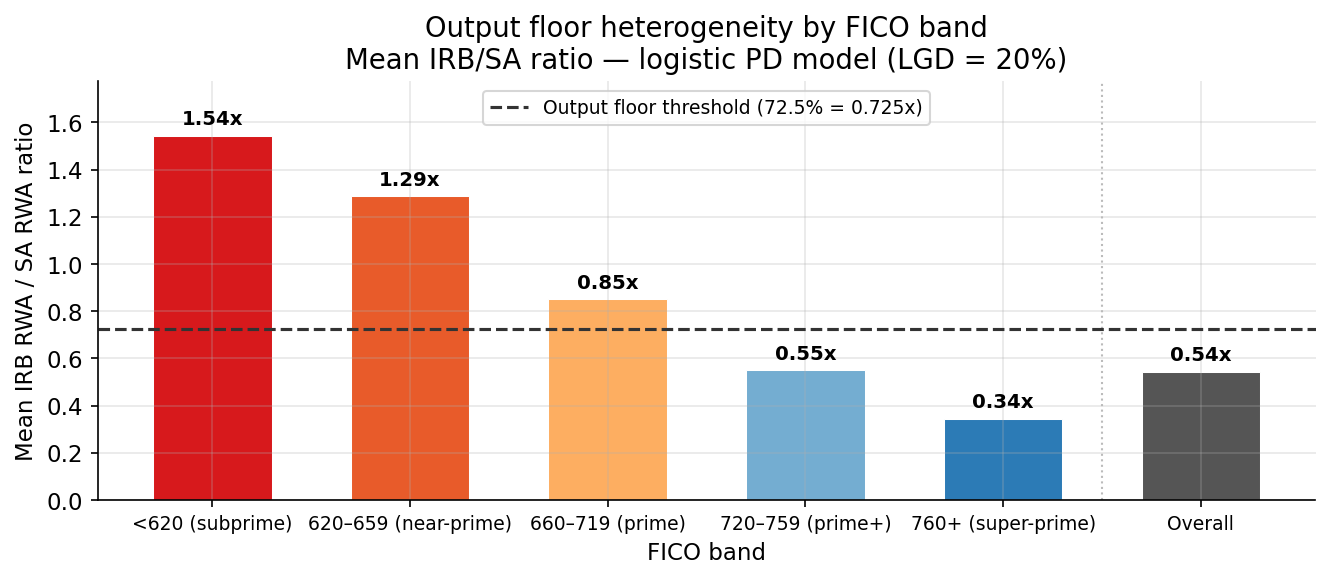

Saved fig9_irb_sa_ratio_by_fico.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

colours = ["#d7191c", "#e85b2a", "#fdae61", "#74add1", "#2c7bb6"]

# Append a portfolio-wide "Overall" bar so the headline figure
# (mean ratio across the whole book) sits alongside the per-band bars
overall_ratio = df["floor_ratio"].mean()
labels  = band_stats["fico_band"].astype(str).tolist() + ["Overall"]
values  = band_stats["mean_ratio"].tolist() + [overall_ratio]
barcols = colours + ["#555555"]
x       = np.arange(len(labels))

bars = ax.bar(
    x, values,
    color=barcols,
    edgecolor="white",
    linewidth=0.5,
    width=0.6,
)
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Dotted separator between per-band bars and the portfolio aggregate
ax.axvline(len(band_stats) - 0.5, color="#bbbbbb", linewidth=1, linestyle=":")

# Label each bar with the exact ratio
for bar, ratio in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{ratio:.2f}x",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold"
    )

# Draw the output floor threshold line
ax.axhline(
    OUTPUT_FLOOR,
    color="#333333",
    linewidth=1.5,
    linestyle="--",
    label=f"Output floor threshold ({OUTPUT_FLOOR*100:.1f}% = 0.725x)"
)

ax.set_xlabel("FICO band")
ax.set_ylabel("Mean IRB RWA / SA RWA ratio")
ax.set_title(
    "Output floor heterogeneity by FICO band\n"
    f"Mean IRB/SA ratio — logistic PD model (LGD = {IRB_LGD_BASE*100:.0f}%)"
)
ax.tick_params(axis="x", labelsize=9)
ax.legend(fontsize=9)
ax.set_ylim(0, max(values) * 1.15)

plt.tight_layout()
path = OUTPUTS_DIR / "fig9_irb_sa_ratio_by_fico.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {path.name}")

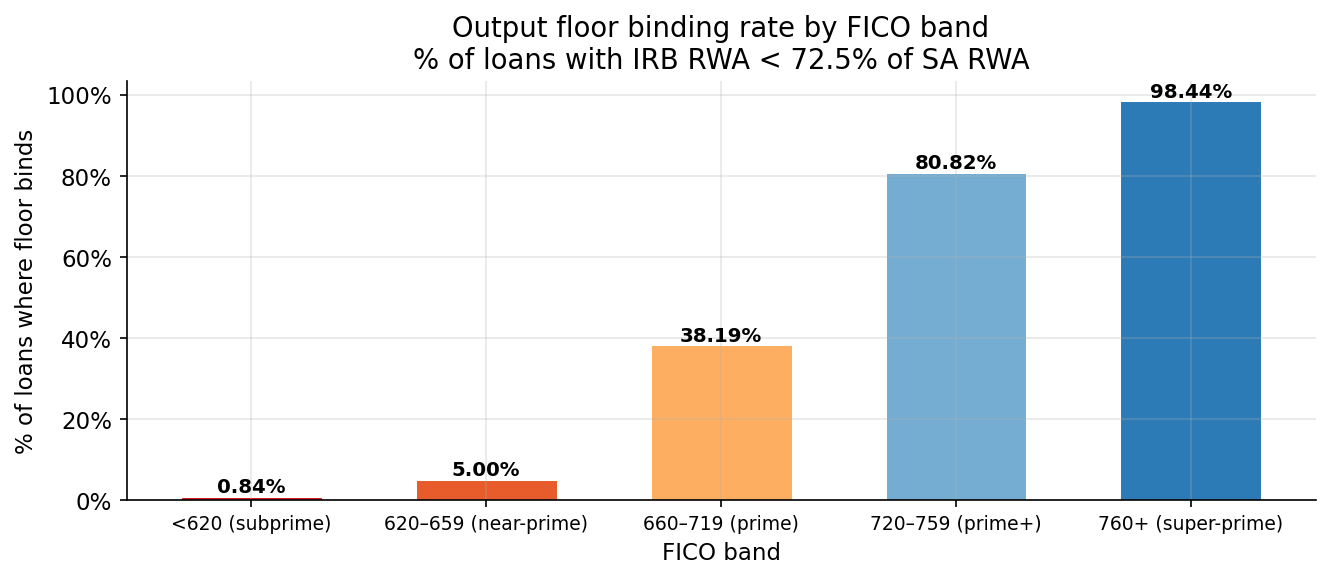

Saved fig10_floor_bind_rate_by_fico.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

colours = ["#d7191c", "#e85b2a", "#fdae61", "#74add1", "#2c7bb6"]
bars = ax.bar(
    band_stats["fico_band"].astype(str),
    band_stats["bind_rate_pct"],
    color=colours,
    edgecolor="white",
    linewidth=0.5,
    width=0.6,
)

for bar, rate in zip(bars, band_stats["bind_rate_pct"]):
    label = f"{rate:.2f}%" if rate > 0 else "0.00%"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        label,
        ha="center", va="bottom", fontsize=9.5, fontweight="bold"
    )

ax.set_xlabel("FICO band")
ax.set_ylabel("% of loans where floor binds")
ax.set_title(
    "Output floor binding rate by FICO band\n"
    "% of loans with IRB RWA < 72.5% of SA RWA"
)
ax.tick_params(axis="x", labelsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
path = OUTPUTS_DIR / "fig10_floor_bind_rate_by_fico.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {path.name}")

/tmp/claude-501/ipykernel_64634/2376299284.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby("fico_band", observed=True).apply(
/tmp/claude-501/ipykernel_64634/2376299284.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


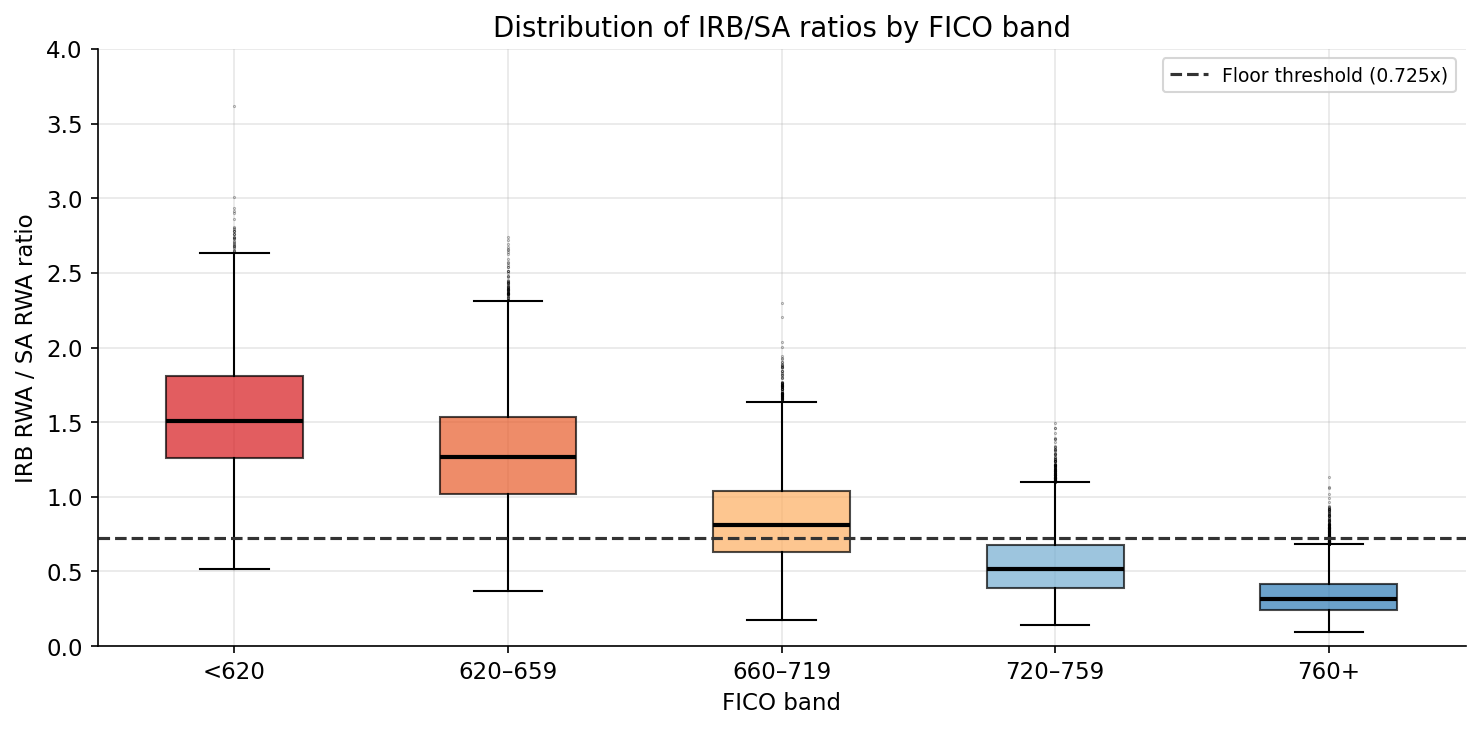

Saved fig11_ratio_distribution_boxplot.png


In [7]:
# Box plot showing the full distribution of IRB/SA ratios by FICO band
# This is more informative than the mean alone — it shows the spread
# and where the floor-binding tail sits for each segment

fig, ax = plt.subplots(figsize=(10, 5))

# Sample for plotting — box plots on 4M loans are slow
# 50,000 stratified sample is visually identical
sample = df.groupby("fico_band", observed=True).apply(
    lambda x: x.sample(min(len(x), 10000), random_state=42)
).reset_index(drop=True)

bands  = sample["fico_band"].cat.categories.tolist()
data   = [sample.loc[sample["fico_band"] == b, "floor_ratio"].dropna().values
          for b in bands]

bp = ax.boxplot(
    data,
    labels=[b.split(" ")[0] for b in bands],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker=".", markersize=1, alpha=0.3),
    widths=0.5,
)

colours = ["#d7191c", "#e85b2a", "#fdae61", "#74add1", "#2c7bb6"]
for patch, colour in zip(bp["boxes"], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

# Draw the floor threshold
ax.axhline(OUTPUT_FLOOR, color="#333333", linewidth=1.5,
           linestyle="--", label="Floor threshold (0.725x)")

ax.set_xlabel("FICO band")
ax.set_ylabel("IRB RWA / SA RWA ratio")
ax.set_title("Distribution of IRB/SA ratios by FICO band")
ax.legend(fontsize=9)
ax.set_ylim(0, 4)   # cap y-axis at 4 for readability — subprime has extreme outliers above this

plt.tight_layout()
path = OUTPUTS_DIR / "fig11_ratio_distribution_boxplot.png"
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved {path.name}")

In [8]:
# ── Portfolio-level summary ───────────────────────────────────────
# The output floor is an AGGREGATE rule: it applies to TOTAL portfolio RWA,
# not loan by loan. So the floored RWA and the extra RWA / capital it imposes
# must be computed at the portfolio level — the binding floor takes
#     max( total IRB RWA , 72.5% x total SA RWA )
# which nets the headroom of loans above the floor against the shortfall of
# loans below it. Summing loan-level uplifts would OVERSTATE the impact.
total_irb_rwa   = df["irb_rwa_logistic"].sum()
total_sa_rwa    = df["sa_rwa"].sum()
total_floor_rwa = total_sa_rwa * OUTPUT_FLOOR            # 72.5% of aggregate SA RWA
floored_rwa     = max(total_irb_rwa, total_floor_rwa)    # binding floor takes the max
aggregate_uplift  = floored_rwa - total_irb_rwa         # extra RWA imposed by the floor
aggregate_capital = aggregate_uplift * 0.08             # extra capital at the 8% minimum
aggregate_ratio   = total_irb_rwa / total_sa_rwa        # the RWA-weighted IRB/SA ratio
                                                        # that actually drives the floor

portfolio = pd.DataFrame([{
    "loans"                   : len(df),
    "n_binds_loanlevel"       : int(df["floor_binds"].sum()),
    "bind_rate_pct_loanlevel" : df["floor_binds"].mean() * 100,
    "mean_ratio_loanlevel"    : df["floor_ratio"].mean(),
    "aggregate_irb_sa_ratio"  : aggregate_ratio,
    "mean_irb_rw_pct"         : df["irb_rw_logistic"].mean() * 100,
    "mean_sa_rw_pct"          : df["sa_rw"].mean() * 100,
    "total_irb_rwa"           : total_irb_rwa,
    "total_sa_rwa"            : total_sa_rwa,
    "aggregate_floor_rwa"     : total_floor_rwa,
    "floored_rwa"             : floored_rwa,
    "aggregate_rwa_uplift"    : aggregate_uplift,
    "aggregate_extra_capital" : aggregate_capital,
}])

print("H1 — portfolio-level output floor summary (AGGREGATE basis):")
print("=" * 64)
print(f"  Loans                          : {portfolio['loans'][0]:,}")
print(f"  Aggregate IRB/SA ratio         : {aggregate_ratio:.3f}x")
print(f"  Total IRB RWA                  : {total_irb_rwa:,.0f} USD")
print(f"  Total SA RWA                   : {total_sa_rwa:,.0f} USD")
print(f"  Aggregate floor (72.5% of SA)  : {total_floor_rwa:,.0f} USD")
print(f"  Floored RWA = max(IRB, floor)  : {floored_rwa:,.0f} USD")
print(f"  Aggregate RWA uplift           : {aggregate_uplift:,.0f} USD")
print(f"  Aggregate extra capital (x8%)  : {aggregate_capital:,.0f} USD")

portfolio.to_csv(OUTPUTS_DIR / "table5_portfolio_summary.csv", index=False)
print("\nSaved table5_portfolio_summary.csv")


H1 — portfolio-level output floor summary (AGGREGATE basis):
  Loans                          : 4,464,305
  Aggregate IRB/SA ratio         : 0.541x
  Total IRB RWA                  : 196,423,789,683 USD
  Total SA RWA                   : 363,038,825,400 USD
  Aggregate floor (72.5% of SA)  : 263,203,148,415 USD
  Floored RWA = max(IRB, floor)  : 263,203,148,415 USD
  Aggregate RWA uplift           : 66,779,358,732 USD
  Aggregate extra capital (x8%)  : 5,342,348,699 USD

Saved table5_portfolio_summary.csv
